## Seleccionar top dos modelos pata PCA/UMAP

Poner quemados los datos observados de los modelos

In [4]:
import pandas as pd

model_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc_val": 0.7966,
        "roc_auc_test": 0.7925,
        "accuracy_test": 0.7317,
        "precision_test": 0.7656,
        "recall_test": 0.6601,
        "f1_test": 0.7090,
        "f2_test": 0.686191,
        "FN_test": 1127,
        "FP_test": 678,
    },
    {
        "model": "KNN",
        "roc_auc_val": 0.799542,
        "roc_auc_test": 0.798452,
        "accuracy_test": 0.579822,
        "precision_test": 0.542488,
        "recall_test": 0.964654,
        "f1_test": 0.694444,
        "f2_test": 0.834735,
        "FN_test": 120,
        "FP_test": 2762,
    },
    {
        "model": "Random Forest",
        "roc_auc_val": 0.8065,
        "roc_auc_test": 0.8036,
        "accuracy_test": 0.7368,
        "precision_test": 0.7699,
        "recall_test": 0.6680,
        "f1_test": 0.7153,
        "f2_test": 0.686191,
        "FN_test": 1127,
        "FP_test": 678,
    },
    {
        "model": "SVM",
        "roc_auc_val": 0.800442,
        "roc_auc_test": 0.795748,
        "accuracy_test": 0.539146,
        "precision_test": 0.518190,
        "recall_test": 0.981738,
        "f1_test": 0.678335,
        "f2_test": 0.832750,
        "FN_test": 62,
        "FP_test": 3099,
    },
    {
        "model": "MLP",
        "roc_auc_val": 0.806683,
        "roc_auc_test": 0.804413,
        "accuracy_test": 0.599650,
        "precision_test": 0.555385,
        "recall_test": 0.958468,
        "f1_test": 0.703263,
        "f2_test": 0.836977,
        "FN_test": 141,
        "FP_test": 2605,
    },
])

model_results

,model,roc_auc_val,roc_auc_test,accuracy_test,precision_test,recall_test,f1_test,f2_test,FN_test,FP_test
0,Logistic Regression,0.796600,0.792500,0.731700,0.765600,0.660100,0.709000,0.686191,1127,678
1,KNN,0.799542,0.798452,0.579822,0.542488,0.964654,0.694444,0.834735,120,2762
2,Random Forest,0.806500,0.803600,0.736800,0.769900,0.668000,0.715300,0.686191,1127,678
3,SVM,0.800442,0.795748,0.539146,0.518190,0.981738,0.678335,0.832750,62,3099
4,MLP,0.806683,0.804413,0.599650,0.555385,0.958468,0.703263,0.836977,141,2605


Ordenamos

In [5]:
model_results_sorted = model_results.sort_values(
    by=["roc_auc_val", "roc_auc_test", "f2_test"],
    ascending=[False, False, False]
).reset_index(drop=True)

model_results_sorted

,model,roc_auc_val,roc_auc_test,accuracy_test,precision_test,recall_test,f1_test,f2_test,FN_test,FP_test
0,MLP,0.806683,0.804413,0.599650,0.555385,0.958468,0.703263,0.836977,141,2605
1,Random Forest,0.806500,0.803600,0.736800,0.769900,0.668000,0.715300,0.686191,1127,678
2,SVM,0.800442,0.795748,0.539146,0.518190,0.981738,0.678335,0.832750,62,3099
3,KNN,0.799542,0.798452,0.579822,0.542488,0.964654,0.694444,0.834735,120,2762
4,Logistic Regression,0.796600,0.792500,0.731700,0.765600,0.660100,0.709000,0.686191,1127,678


In [6]:
final_model = model_results_sorted.iloc[0]
top2_models = model_results_sorted.head(2)

print("Modelo final:")
print(final_model)

print("\nTop 2 para PCA/UMAP:")
print(top2_models[["model", "roc_auc_val", "roc_auc_test", "f2_test"]])

Modelo final:
model                  MLP
roc_auc_val       0.806683
roc_auc_test      0.804413
accuracy_test      0.59965
precision_test    0.555385
recall_test       0.958468
f1_test           0.703263
f2_test           0.836977
FN_test                141
FP_test               2605
Name: 0, dtype: object

Top 2 para PCA/UMAP:
           model  roc_auc_val  roc_auc_test   f2_test
0            MLP     0.806683      0.804413  0.836977
1  Random Forest     0.806500      0.803600  0.686191


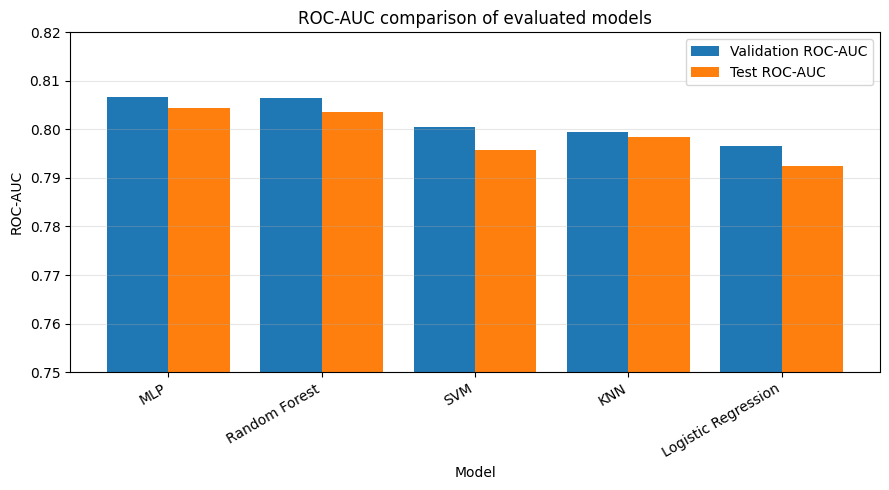

Guardado en: ReportAssets\figures\model_roc_auc_comparison.png


In [7]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path("ReportAssets") / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plot_df = model_results.sort_values("roc_auc_val", ascending=False).reset_index(drop=True)

x = range(len(plot_df))
plt.figure(figsize=(9, 5))

plt.bar([i - 0.2 for i in x], plot_df["roc_auc_val"], width=0.4, label="Validation ROC-AUC")
plt.bar([i + 0.2 for i in x], plot_df["roc_auc_test"], width=0.4, label="Test ROC-AUC")

plt.xticks(x, plot_df["model"], rotation=30, ha="right")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC comparison of evaluated models")
plt.ylim(0.75, 0.82)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_path = FIGURES_DIR / "model_roc_auc_comparison.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Guardado en:", output_path)